/tmp/ipykernel_371313/1677525683.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(data=df_1000, x="Model", y="FPR", palette=custom_palette)


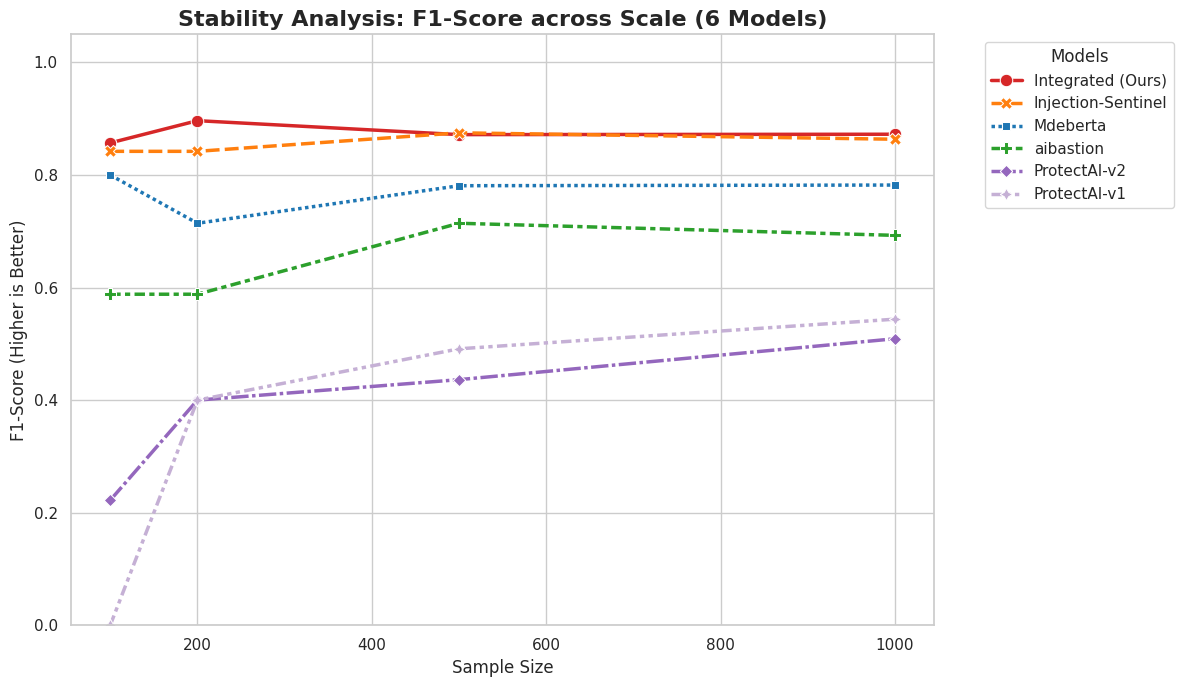

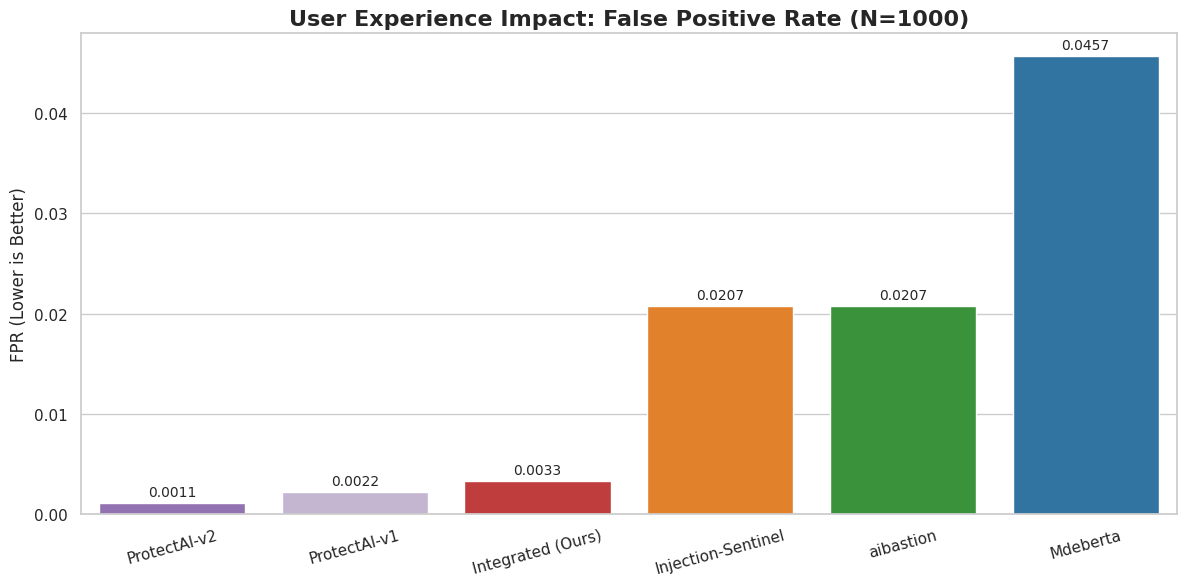

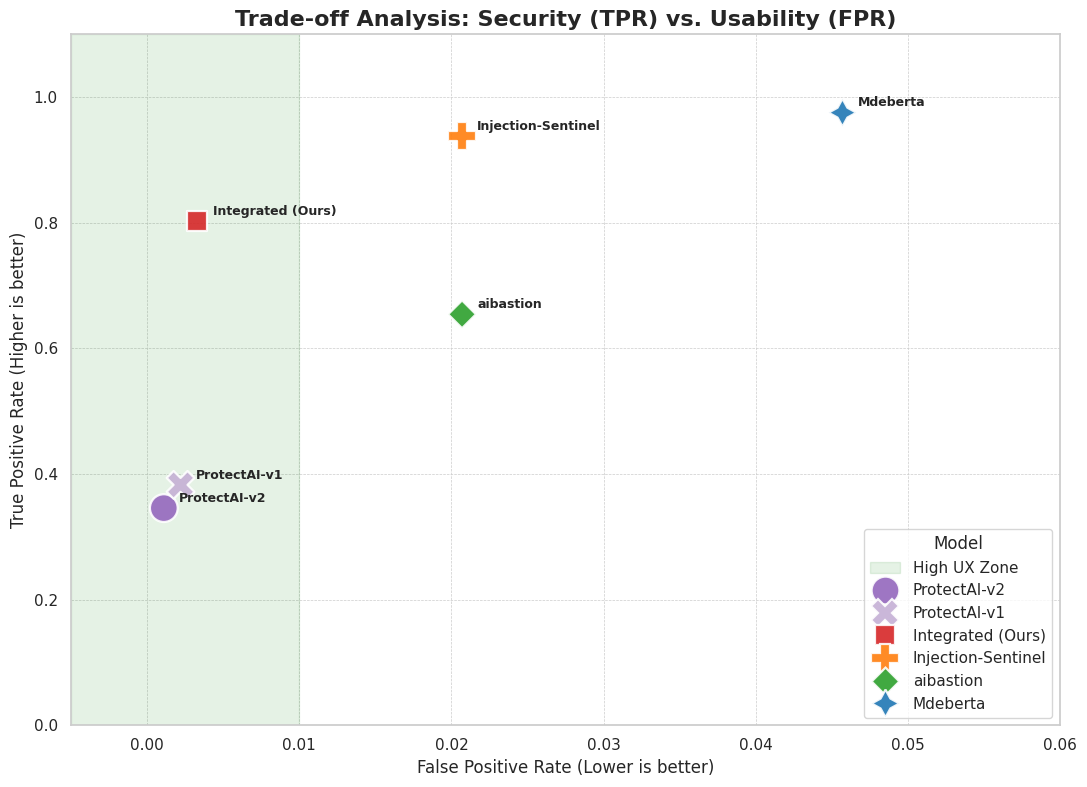

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Cập nhật dữ liệu ĐẦY ĐỦ từ log của bạn
data = {
    "Sample Size": [100, 200, 500, 1000] * 6, # 6 Models
    "Model": (
        ["Integrated (Ours)"] * 4 + 
        ["Injection-Sentinel"] * 4 + 
        ["Mdeberta"] * 4 + 
        ["aibastion"] * 4 +
        ["ProtectAI-v2"] * 4 +
        ["ProtectAI-v1"] * 4
    ),
    "F1-Score": [
        # Integrated
        0.8571, 0.8966, 0.8718, 0.8725,
        # Injection-Sentinel
        0.8421, 0.8421, 0.8750, 0.8636,
        # Mdeberta
        0.8000, 0.7143, 0.7810, 0.7822,
        # aibastion
        0.5882, 0.5882, 0.7143, 0.6928,
        # ProtectAI-v2
        0.2222, 0.4000, 0.4364, 0.5091,
        # ProtectAI-v1
        0.0000, 0.4000, 0.4912, 0.5439
    ],
    "FPR": [
        # Integrated
        0.0000, 0.0000, 0.0044, 0.0033,
        # Injection-Sentinel
        0.0326, 0.0326, 0.0262, 0.0207,
        # Mdeberta
        0.0435, 0.0598, 0.0480, 0.0457,
        # aibastion
        0.0435, 0.0435, 0.0262, 0.0207,
        # ProtectAI-v2
        0.0000, 0.0000, 0.0022, 0.0011,
        # ProtectAI-v1
        0.0000, 0.0000, 0.0022, 0.0022
    ],
    "TPR": [
        # Integrated
        0.7500, 0.8125, 0.8095, 0.8025,
        # Injection-Sentinel
        1.0000, 1.0000, 1.0000, 0.9383,
        # Mdeberta
        1.0000, 0.9375, 0.9762, 0.9753,
        # aibastion
        0.6250, 0.6250, 0.7143, 0.6543,
        # ProtectAI-v2
        0.1250, 0.2500, 0.2857, 0.3457,
        # ProtectAI-v1
        0.0000, 0.2500, 0.3333, 0.3827
    ]
}

df = pd.DataFrame(data)

# Cấu hình hiển thị
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})
# Palette màu sắc nét: Ours (Đỏ đậm), Sentinel (Cam), Mdeberta (Xanh dương), còn lại nhạt hơn
custom_palette = {
    "Integrated (Ours)": "#D62728",      # Red (Nổi bật nhất)
    "Injection-Sentinel": "#FF7F0E",     # Orange (Đối thủ chính)
    "Mdeberta": "#1F77B4",               # Blue (FPR cao)
    "aibastion": "#2CA02C",              # Green
    "ProtectAI-v2": "#9467BD",           # Purple
    "ProtectAI-v1": "#C5B0D5"            # Light Purple
}

# --- BIỂU ĐỒ 1: Stability Analysis (F1-Score) ---
plt.figure(figsize=(12, 7))
sns.lineplot(data=df, x="Sample Size", y="F1-Score", hue="Model", style="Model", 
             palette=custom_palette, markers=True, linewidth=2.5, markersize=9)
plt.title("Stability Analysis: F1-Score across Scale (6 Models)", fontsize=16, fontweight='bold')
plt.ylabel("F1-Score (Higher is Better)")
plt.ylim(0.0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Models")
plt.tight_layout()
plt.savefig("full_stability_f1.png")

# --- BIỂU ĐỒ 2: False Positive Rate (UX Impact) at N=1000 ---
df_1000 = df[df["Sample Size"] == 1000].sort_values("FPR", ascending=True)

plt.figure(figsize=(12, 6))
bar = sns.barplot(data=df_1000, x="Model", y="FPR", palette=custom_palette)
plt.title("User Experience Impact: False Positive Rate (N=1000)", fontsize=16, fontweight='bold')
plt.ylabel("FPR (Lower is Better)")
plt.xlabel("")
plt.xticks(rotation=15) # Xoay tên model cho dễ đọc

# Annotate values
for p in bar.patches:
    height = p.get_height()
    bar.annotate(f'{height:.4f}', 
                   (p.get_x() + p.get_width() / 2., height), 
                   ha = 'center', va = 'bottom', 
                   xytext = (0, 3), 
                   textcoords = 'offset points', fontsize=10)

plt.tight_layout()
plt.savefig("full_fpr_comparison.png")

# --- BIỂU ĐỒ 3: Security vs Usability Trade-off (N=1000) ---
plt.figure(figsize=(11, 8))
# Vẽ vùng an toàn (Ideal Zone)
plt.axvspan(-0.005, 0.01, color='green', alpha=0.1, label='High UX Zone')

sns.scatterplot(data=df_1000, x="FPR", y="TPR", hue="Model", style="Model", 
                palette=custom_palette, s=400, alpha=0.9)

plt.title("Trade-off Analysis: Security (TPR) vs. Usability (FPR)", fontsize=16, fontweight='bold')
plt.xlabel("False Positive Rate (Lower is better)")
plt.ylabel("True Positive Rate (Higher is better)")
plt.xlim(-0.005, 0.06)
plt.ylim(0.0, 1.1)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Thêm tên model ngay cạnh điểm
for i in range(df_1000.shape[0]):
    row = df_1000.iloc[i]
    plt.text(row.FPR + 0.001, row.TPR + 0.01, row.Model, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("full_tradeoff_scatter.png")

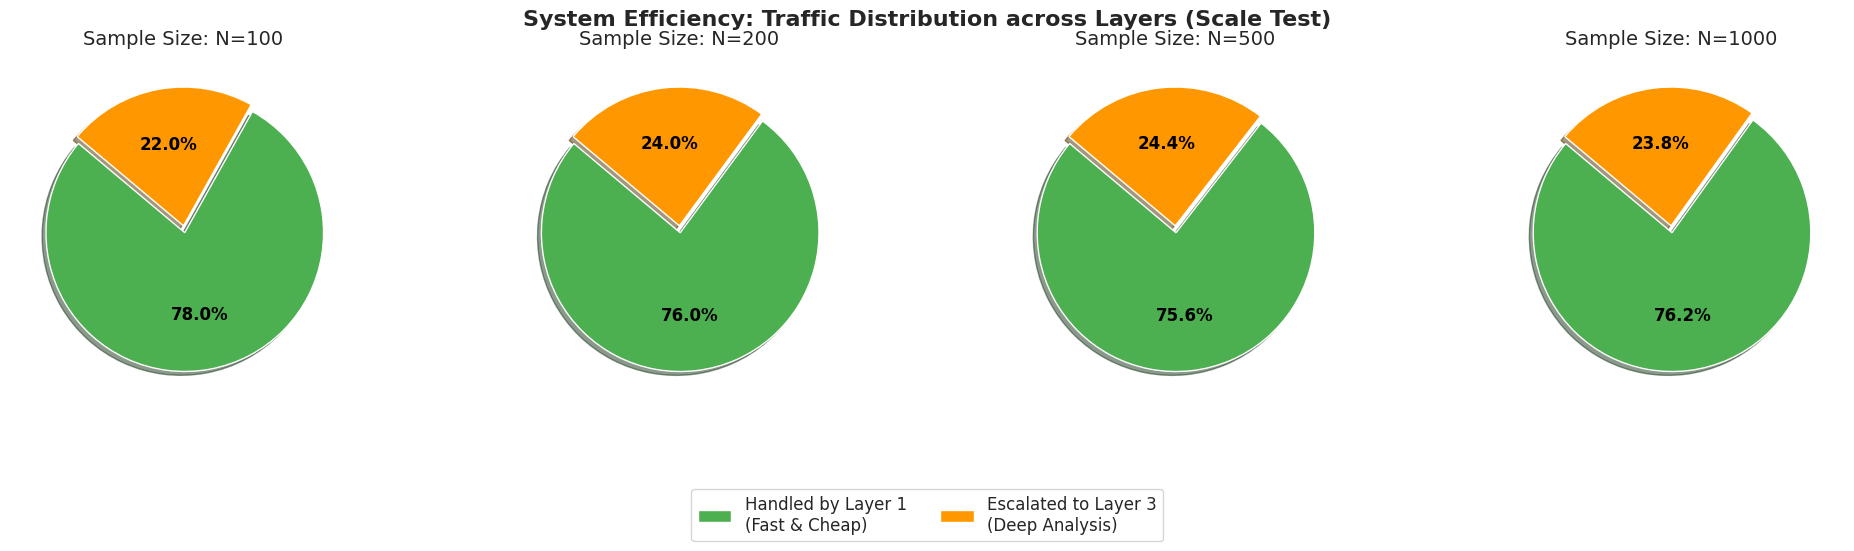

In [2]:
import matplotlib.pyplot as plt

# 1. Dữ liệu từ các lần chạy benchmark của bạn
# L3 Trigger Rate (%) lấy từ log "EFFICIENCY & LATENCY"
experiments = [
    {"n": 100,  "l3_trigger": 22.00},
    {"n": 200,  "l3_trigger": 24.00},
    {"n": 500,  "l3_trigger": 24.40},
    {"n": 1000, "l3_trigger": 23.80}
]

# Cấu hình màu sắc:
# - Màu xanh (Cool color): Tượng trưng cho xử lý nhanh tại Layer 1 (An toàn/Tiết kiệm)
# - Màu cam (Warm color): Tượng trưng cho xử lý sâu tại Layer 3 (Tốn kém/Kỹ lưỡng)
colors = ['#4CAF50', '#FF9800'] # Green vs Orange
labels = ['Handled by Layer 1\n(Fast & Cheap)', 'Escalated to Layer 3\n(Deep Analysis)']
explode = (0.05, 0)  # Tách nhẹ phần Layer 1 ra để làm nổi bật

# 2. Tạo khung hình vẽ (1 hàng, 4 cột)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('System Efficiency: Traffic Distribution across Layers (Scale Test)', fontsize=16, fontweight='bold')

for i, exp in enumerate(experiments):
    n = exp["n"]
    l3_rate = exp["l3_trigger"]
    l1_rate = 100 - l3_rate # Phần còn lại được xử lý bởi Layer 1
    
    sizes = [l1_rate, l3_rate]
    
    # Vẽ Pie Chart trên từng trục (axes)
    wedges, texts, autotexts = axes[i].pie(
        sizes, 
        explode=explode, 
        labels=None, # Tắt label ở pie để đỡ rối, sẽ dùng legend chung
        colors=colors, 
        autopct='%1.1f%%', 
        shadow=True, 
        startangle=140,
        textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'white'}
    )
    
    # Tiêu đề cho từng biểu đồ con
    axes[i].set_title(f'Sample Size: N={n}', fontsize=14)
    
    # Tinh chỉnh màu chữ % cho dễ đọc
    for autotext in autotexts:
        autotext.set_color('black') # Hoặc white tùy màu nền pie

# 3. Tạo Legend chung ở phía dưới
fig.legend(wedges, labels, loc="lower center", ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.1))

plt.tight_layout()
plt.subplots_adjust(bottom=0.2) # Chừa chỗ cho Legend
plt.savefig("efficiency_pie_charts.png", dpi=300, bbox_inches='tight')
plt.show()

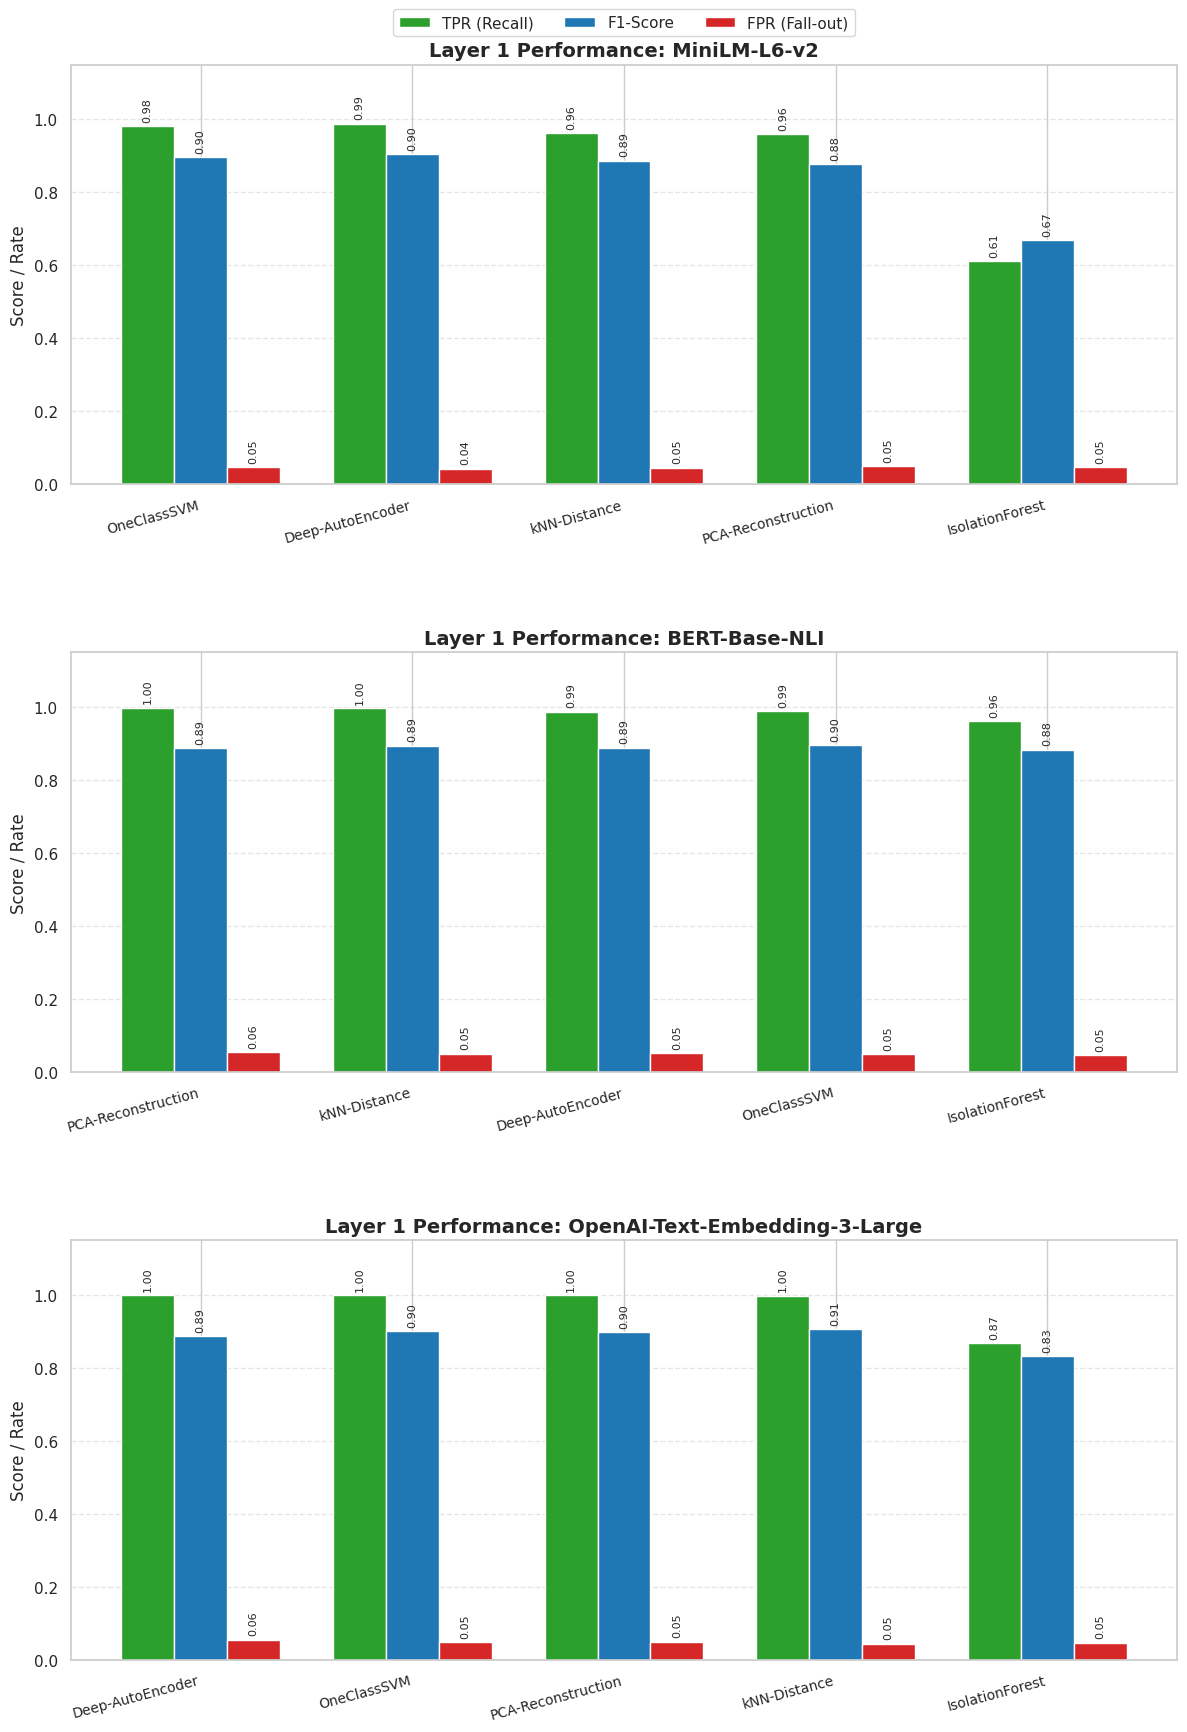

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU
# ==========================================

# Dữ liệu cho MiniLM
data_minilm = {
    "OneClassSVM":      [0.9819, 0.8953, 0.0466],
    "Deep-AutoEncoder": [0.9879, 0.9046, 0.0433],
    "kNN-Distance":     [0.9622, 0.8866, 0.0460],
    "PCA-Reconstruction": [0.9592, 0.8777, 0.0500],
    "IsolationForest":  [0.6118, 0.6689, 0.0480]
}

# Dữ liệu cho BERT (Quan trọng nhất)
data_bert = {
    "PCA-Reconstruction": [0.9985, 0.8867, 0.0559], # The Chosen One
    "kNN-Distance":     [0.9970, 0.8943, 0.0513],
    "Deep-AutoEncoder": [0.9879, 0.8892, 0.0516],
    "OneClassSVM":      [0.9894, 0.8954, 0.0486],
    "IsolationForest":  [0.9622, 0.8835, 0.0476]
}

# Dữ liệu cho OpenAI Large
data_large = {
    "Deep-AutoEncoder": [1.0000, 0.8874, 0.0559],
    "OneClassSVM":      [1.0000, 0.9007, 0.0486],
    "PCA-Reconstruction": [1.0000, 0.8976, 0.0503],
    "kNN-Distance":     [0.9985, 0.9061, 0.0453],
    "IsolationForest":  [0.8671, 0.8319, 0.0480]
}

datasets = [
    ("MiniLM-L6-v2", data_minilm), 
    ("BERT-Base-NLI", data_bert), 
    ("OpenAI-Text-Embedding-3-Large", data_large)
]

# ==========================================
# 2. THIẾT LẬP VẼ BIỂU ĐỒ
# ==========================================

# Cấu hình màu sắc
# TPR: Xanh lá (Tốt), F1: Xanh dương (Trung hòa), FPR: Đỏ (Cảnh báo)
colors = ['#2ca02c', '#1f77b4', '#d62728'] 
labels = ['TPR (Recall)', 'F1-Score', 'FPR (Fall-out)']

def plot_grouped_bar(ax, data, title_prefix):
    models = list(data.keys())
    values = np.array(list(data.values()))
    
    # Vị trí các nhóm
    x = np.arange(len(models))
    width = 0.25  # Độ rộng của mỗi cột
    
    # Vẽ 3 cột: TPR (Trái), F1 (Giữa), FPR (Phải)
    rects1 = ax.bar(x - width, values[:, 0], width, label=labels[0], color=colors[0], edgecolor='white')
    rects2 = ax.bar(x,         values[:, 1], width, label=labels[1], color=colors[1], edgecolor='white')
    rects3 = ax.bar(x + width, values[:, 2], width, label=labels[2], color=colors[2], edgecolor='white')

    # Trang trí trục
    ax.set_ylabel('Score / Rate')
    ax.set_title(f'Layer 1 Performance: {title_prefix}', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
    ax.set_ylim(0, 1.15) # Để chừa chỗ cho text label
    
    # Thêm lưới ngang cho dễ nhìn
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Hàm hiển thị giá trị lên đầu cột
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, rotation=90)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

# ==========================================
# 3. THỰC HIỆN VẼ
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Vẽ lần lượt 3 biểu đồ
for i, (name, data) in enumerate(datasets):
    plot_grouped_bar(axes[i], data, name)
    # Chỉ hiện Legend ở biểu đồ đầu tiên để đỡ rối, hoặc biểu đồ cuối
    if i == 0:
        axes[i].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.93, hspace=0.4) # Điều chỉnh khoảng cách
plt.savefig("layer1_comparison_grouped_bars.png", dpi=300)
plt.show()

[OK] Saved chart: layer1_minilm_chart.png


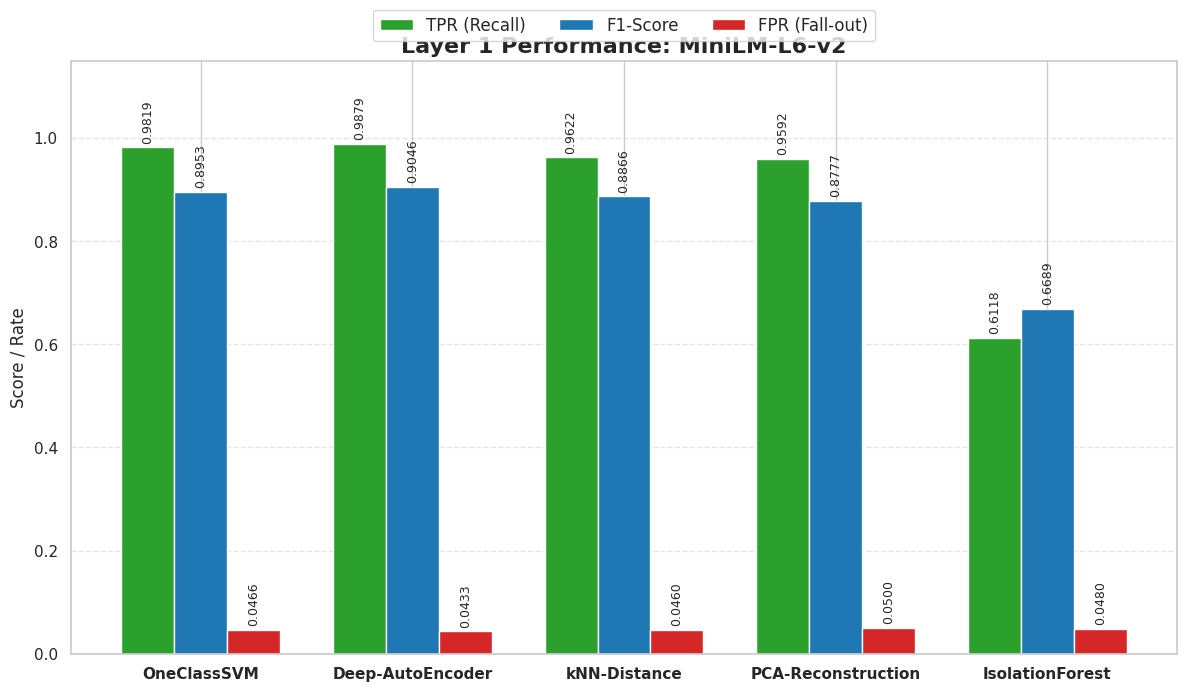

[OK] Saved chart: layer1_bert_chart.png


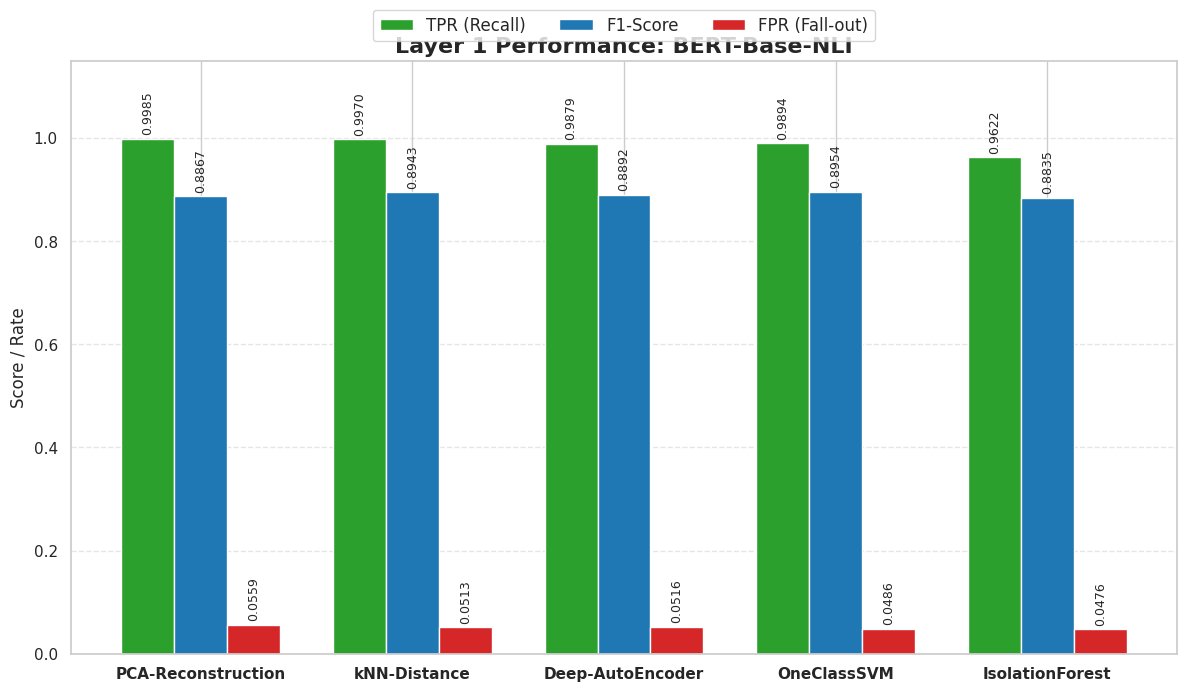

[OK] Saved chart: layer1_openai_large_chart.png


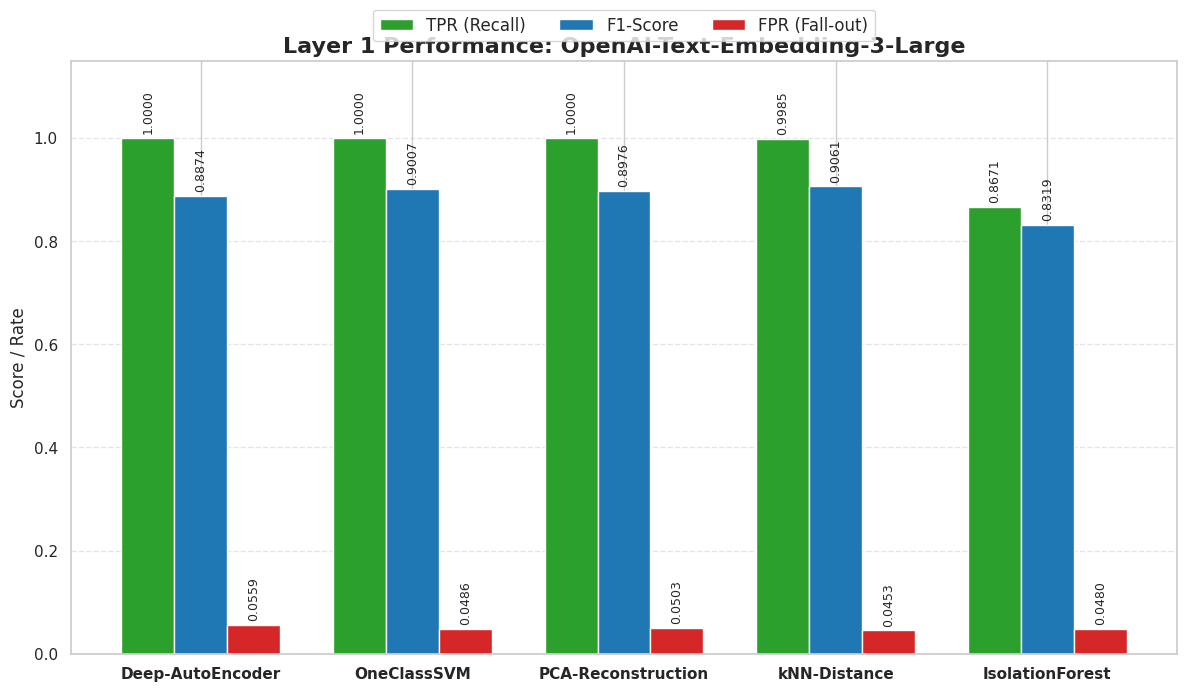

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU
# ==========================================
data_minilm = {
    "OneClassSVM":      [0.9819, 0.8953, 0.0466],
    "Deep-AutoEncoder": [0.9879, 0.9046, 0.0433],
    "kNN-Distance":     [0.9622, 0.8866, 0.0460],
    "PCA-Reconstruction": [0.9592, 0.8777, 0.0500],
    "IsolationForest":  [0.6118, 0.6689, 0.0480]
}

data_bert = {
    "PCA-Reconstruction": [0.9985, 0.8867, 0.0559], 
    "kNN-Distance":     [0.9970, 0.8943, 0.0513],
    "Deep-AutoEncoder": [0.9879, 0.8892, 0.0516],
    "OneClassSVM":      [0.9894, 0.8954, 0.0486],
    "IsolationForest":  [0.9622, 0.8835, 0.0476]
}

data_large = {
    "Deep-AutoEncoder": [1.0000, 0.8874, 0.0559],
    "OneClassSVM":      [1.0000, 0.9007, 0.0486],
    "PCA-Reconstruction": [1.0000, 0.8976, 0.0503],
    "kNN-Distance":     [0.9985, 0.9061, 0.0453],
    "IsolationForest":  [0.8671, 0.8319, 0.0480]
}

# Danh sách các tập dữ liệu để chạy vòng lặp
datasets = [
    ("MiniLM-L6-v2", data_minilm, "layer1_minilm_chart.png"), 
    ("BERT-Base-NLI", data_bert, "layer1_bert_chart.png"), 
    ("OpenAI-Text-Embedding-3-Large", data_large, "layer1_openai_large_chart.png")
]

# ==========================================
# 2. HÀM VẼ BIỂU ĐỒ (Dùng chung)
# ==========================================
colors = ['#2ca02c', '#1f77b4', '#d62728'] # Xanh lá (TPR), Xanh dương (F1), Đỏ (FPR)
labels = ['TPR (Recall)', 'F1-Score', 'FPR (Fall-out)']

def create_single_chart(title_name, data_dict, filename):
    models = list(data_dict.keys())
    values = np.array(list(data_dict.values()))
    
    x = np.arange(len(models))
    width = 0.25 
    
    # Tạo figure mới cho mỗi biểu đồ
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Vẽ 3 cột
    rects1 = ax.bar(x - width, values[:, 0], width, label=labels[0], color=colors[0], edgecolor='white')
    rects2 = ax.bar(x,         values[:, 1], width, label=labels[1], color=colors[1], edgecolor='white')
    rects3 = ax.bar(x + width, values[:, 2], width, label=labels[2], color=colors[2], edgecolor='white')

    # Trang trí
    ax.set_ylabel('Score / Rate')
    ax.set_title(f'Layer 1 Performance: {title_name}', fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.15) 
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Thêm Legend vào từng biểu đồ
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3, fontsize=12)

    # Hiển thị số liệu trên đầu cột
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}', # Lấy 4 chữ số thập phân cho chi tiết
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, rotation=90)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300) # Lưu file riêng biệt
    print(f"[OK] Saved chart: {filename}")
    plt.show()

# ==========================================
# 3. CHẠY VÒNG LẶP VẼ VÀ LƯU FILE
# ==========================================
for name, data, fname in datasets:
    create_single_chart(name, data, fname)

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Tạo thư mục lưu ảnh nếu chưa có
if not os.path.exists("charts"):
    os.makedirs("charts")

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU
# ==========================================
data_minilm = {
    "OneClassSVM":      [0.9819, 0.8953, 0.0466],
    "Deep-AutoEncoder": [0.9879, 0.9046, 0.0433],
    "kNN-Distance":     [0.9622, 0.8866, 0.0460],
    "PCA-Reconstruction": [0.9592, 0.8777, 0.0500],
    "IsolationForest":  [0.6118, 0.6689, 0.0480]
}

data_bert = {
    "PCA-Reconstruction": [0.9985, 0.8867, 0.0559], 
    "kNN-Distance":     [0.9970, 0.8943, 0.0513],
    "Deep-AutoEncoder": [0.9879, 0.8892, 0.0516],
    "OneClassSVM":      [0.9894, 0.8954, 0.0486],
    "IsolationForest":  [0.9622, 0.8835, 0.0476]
}

data_large = {
    "Deep-AutoEncoder": [1.0000, 0.8874, 0.0559],
    "OneClassSVM":      [1.0000, 0.9007, 0.0486],
    "PCA-Reconstruction": [1.0000, 0.8976, 0.0503],
    "kNN-Distance":     [0.9985, 0.9061, 0.0453],
    "IsolationForest":  [0.8671, 0.8319, 0.0480]
}

datasets = [
    ("MiniLM-L6-v2", data_minilm, "charts/layer1_minilm_chart.png"), 
    ("BERT-Base-NLI", data_bert, "charts/layer1_bert_chart.png"), 
    ("OpenAI-Text-Embedding-3-Large", data_large, "charts/layer1_openai_large_chart.png")
]

# ==========================================
# 2. HÀM VẼ BIỂU ĐỒ
# ==========================================
# Màu sắc: Xanh lá (TPR), Xanh dương (F1), Đỏ (FPR)
colors = ['#2ca02c', '#1f77b4', '#d62728'] 
labels = ['TPR (Recall)', 'F1-Score', 'FPR (Fall-out)']

def create_single_chart(title_name, data_dict, filename):
    models = list(data_dict.keys())
    values = np.array(list(data_dict.values()))
    
    x = np.arange(len(models))
    width = 0.25 
    
    # Tạo figure mới, kích thước rộng để chứa text ngang
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Vẽ 3 cột
    rects1 = ax.bar(x - width, values[:, 0], width, label=labels[0], color=colors[0], edgecolor='white')
    rects2 = ax.bar(x,         values[:, 1], width, label=labels[1], color=colors[1], edgecolor='white')
    rects3 = ax.bar(x + width, values[:, 2], width, label=labels[2], color=colors[2], edgecolor='white')

    # Trang trí
    ax.set_ylabel('Score / Rate', fontsize=12, fontweight='bold')
    ax.set_title(f'Layer 1 Performance: {title_name}', fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    # KHÔNG XOAY LABEL (rotation=0)
    ax.set_xticklabels(models, fontsize=10, fontweight='bold', rotation=0)
    ax.set_ylim(0, 1.18) # Tăng chiều cao Y để chừa chỗ cho legend
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, fontsize=12)

    # Hiển thị số liệu (KHÔNG XOAY)
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='normal', rotation=0)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    print(f"[OK] Saved chart: {filename}")
    plt.close() # Đóng figure để giải phóng bộ nhớ

# ==========================================
# 3. CHẠY VẼ
# ==========================================
print("--- Generating Bar Charts ---")
for name, data, fname in datasets:
    create_single_chart(name, data, fname)

--- Generating Bar Charts ---
[OK] Saved chart: charts/layer1_minilm_chart.png
[OK] Saved chart: charts/layer1_bert_chart.png
[OK] Saved chart: charts/layer1_openai_large_chart.png
